# Combined Synthetic Trajectory Figure

Plots sample trajectories from **all 7 conditions** of simulated data on a single Letter-sized page.

| Group | Conditions |
|-------|-----------|
| CFD simulations | Unsteady casting, Unsteady circling, Steady casting, Steady circling |
| Unifying model | Laminar, Unsteady, Still air |

**Data sources**
- CFD: `cfd_sim_results_casting.hdf`, `cfd_sim_results_circling.hdf`
- Unifying: `new_unifying.parquet`

**Output:** `combined_synthetic_trajectories.svg` — 8.5 × 11 in, 1 in margins.

**Color code**
- Grey = pre-stimulus (t < 0)
- Red = first `FLASH_END_SEC` seconds after flash onset
- Black + arrowhead = post-stimulus

**Workflow:** edit the *Parameters* cell → Run All.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import PatchCollection
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from pathlib import Path
import pynumdiff

%matplotlib inline
plt.rcParams["figure.dpi"] = 150

## Parameters
Edit the cell below and **Run All** to regenerate the figure.

In [2]:
# ── Layout ───────────────────────────────────────────────────────────────────
N_TRAJ_COLS = 3    # trajectory columns per condition panel
N_TRAJ_ROWS = 3    # trajectory rows per condition panel
N_TRAJS     = N_TRAJ_COLS * N_TRAJ_ROWS   # 9 per condition

# ── Sampling ──────────────────────────────────────────────────────────────────
SEED = 42

# ── Time window ───────────────────────────────────────────────────────────────
MAX_TIME_SEC  = 4.0   # clip trajectories longer than this (s after flash onset)
FLASH_END_SEC = 0.66  # first N seconds after flash onset shown in red

# ── Line style ────────────────────────────────────────────────────────────────
LW           = 0.5    # trajectory line width
ARROW_LENGTH = 0.04   # arrowhead length (metres)

# ── Manual ID toggle ──────────────────────────────────────────────────────────
USE_MANUAL_IDS = True   # set True to use MANUAL_IDS dict below

In [3]:
plt.rcParams["font.family"]     = "sans-serif"
plt.rcParams["font.sans-serif"] = (
    ["Helvetica", "Helvetica Neue", "Arial"] + plt.rcParams["font.sans-serif"]
)
plt.rcParams["text.usetex"] = False
plt.rcParams["font.weight"]  = "normal"

## Plotting helpers

In [4]:
def _mean_angle(angles):
    return np.arctan2(np.mean(np.sin(angles)), np.mean(np.cos(angles)))


def _plot_arrowhead_trajectory(x, y, color="black", arrow_length=0.04,
                               arrow_angle=28, ax=None, linewidth=0.5):
    if len(x) < 2:
        return
    xvel = pynumdiff.finite_difference.second_order(x, 1)[1]
    yvel = pynumdiff.finite_difference.second_order(y, 1)[1]
    last_deg = np.rad2deg(_mean_angle(np.arctan2(yvel, xvel)[-3:]))
    ax.plot(x, y, color=color, linewidth=linewidth, solid_capstyle="butt")
    # Tip placed slightly ahead of last point; wedge opens backward so tip points forward
    cx = x[-1] + np.cos(np.deg2rad(last_deg)) * arrow_length * 0.25
    cy = y[-1] + np.sin(np.deg2rad(last_deg)) * arrow_length * 0.25
    theta1 = last_deg + 180 - arrow_angle / 2
    theta2 = last_deg + 180 + arrow_angle / 2
    wedge = mpatches.Wedge((cx, cy), arrow_length, theta1, theta2)
    ax.add_collection(PatchCollection([wedge], facecolors=color, edgecolors="none"))


def plot_trajectory(df, traj_id, ax, xlim, ylim,
                    flash_end_sec=0.66, max_time_sec=4.0,
                    lw=0.5, arrow_length=0.04, scale_bar=False):
    """Plot one trajectory.

    DataFrame must have columns: obj_id_unique, frame, t_sec, x, y.
    Rows are sorted by 'frame'. Trajectories are clipped at max_time_sec.
    """
    t = (df[df["obj_id_unique"] == traj_id]
         .sort_values("frame")
         .loc[lambda d: d["t_sec"] <= max_time_sec])

    pre  = t[t["t_sec"] < 0]
    dur  = t[(t["t_sec"] >= 0) & (t["t_sec"] <= flash_end_sec)]
    post = t[t["t_sec"] > flash_end_sec]

    if len(post) >= 2:
        _plot_arrowhead_trajectory(post["x"].values, post["y"].values,
                                   color="black", ax=ax, linewidth=lw,
                                   arrow_length=arrow_length)
    if len(pre) >= 2:
        ax.plot(pre["x"], pre["y"], color="grey", alpha=0.8, linewidth=lw,
                solid_capstyle="butt")
    if len(dur) >= 2:
        ax.plot(dur["x"], dur["y"], color="r", linewidth=lw,
                solid_capstyle="butt")

    ax.axis("off")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")

    if scale_bar:
        x0, x1 = xlim
        y0, y1 = ylim
        x_range  = x1 - x0
        bar_size = 0.05
        for cand in [0.1, 0.2]:
            if cand <= 0.25 * x_range:
                bar_size = cand
        bar_x_end   = x1 - 0.05 * x_range
        bar_x_start = bar_x_end - bar_size
        bar_y       = y0 + 0.08 * (y1 - y0)
        ax.plot([bar_x_start, bar_x_end], [bar_y, bar_y],
                color="k", linewidth=1.5, solid_capstyle="butt")
        ax.text((bar_x_start + bar_x_end) / 2, bar_y - 0.03 * (y1 - y0),
                f"{int(bar_size * 100)} cm",
                ha="center", va="top", fontsize=5.5, color="k")

In [5]:
def _mean_angle(angles):
    return np.arctan2(np.mean(np.sin(angles)), np.mean(np.cos(angles)))


def _plot_arrowhead_trajectory(x, y, color="black", arrow_length=0.04,
                               arrow_angle=28, ax=None, linewidth=0.5):
    if len(x) < 2:
        return
    xvel = pynumdiff.finite_difference.second_order(x, 1)[1]
    yvel = pynumdiff.finite_difference.second_order(y, 1)[1]
    last_deg = np.rad2deg(_mean_angle(np.arctan2(yvel, xvel)[-3:]))
    ax.plot(x, y, color=color, linewidth=linewidth, solid_capstyle="butt")
    # Tip placed slightly ahead of last point; wedge opens backward so tip points forward
    cx = x[-1] + np.cos(np.deg2rad(last_deg)) * arrow_length * 0.25
    cy = y[-1] + np.sin(np.deg2rad(last_deg)) * arrow_length * 0.25
    theta1 = last_deg + 180 - arrow_angle / 2
    theta2 = last_deg + 180 + arrow_angle / 2
    wedge = mpatches.Wedge((cx, cy), arrow_length, theta1, theta2)
    ax.add_collection(PatchCollection([wedge], facecolors=color, edgecolors="none"))


def plot_trajectory(df, traj_id, ax, xlim, ylim,
                    flash_end_sec=0.66, max_time_sec=4.0,
                    lw=0.5, arrow_length=0.04, scale_bar=False):
    """Plot one trajectory.

    DataFrame must have columns: obj_id_unique, frame, t_sec, x, y.
    Rows are sorted by 'frame'. Trajectories are clipped at max_time_sec.
    """
    t = (df[df["obj_id_unique"] == traj_id]
         .sort_values("frame")
         .loc[lambda d: d["t_sec"] <= max_time_sec])

    pre  = t[t["t_sec"] < 0]
    dur  = t[(t["t_sec"] >= 0) & (t["t_sec"] <= flash_end_sec)]
    post = t[t["t_sec"] > flash_end_sec]

    if len(post) >= 2:
        _plot_arrowhead_trajectory(post["x"].values, post["y"].values,
                                   color="black", ax=ax, linewidth=lw,
                                   arrow_length=arrow_length)
    if len(pre) >= 2:
        ax.plot(pre["x"], pre["y"], color="grey", alpha=0.8, linewidth=lw,
                solid_capstyle="butt")
    if len(dur) >= 2:
        ax.plot(dur["x"], dur["y"], color="r", linewidth=lw,
                solid_capstyle="butt")

    ax.axis("off")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")

    if scale_bar:
        x0, x1 = xlim
        y0, y1 = ylim
        x_range  = x1 - x0
        bar_size = 0.05
        for cand in [0.1, 0.2]:
            if cand <= 0.25 * x_range:
                bar_size = cand
        bar_x_end   = x1 - 0.05 * x_range
        bar_x_start = bar_x_end - bar_size
        bar_y       = y0 + 0.08 * (y1 - y0)
        ax.plot([bar_x_start, bar_x_end], [bar_y, bar_y],
                color="k", linewidth=1.5, solid_capstyle="butt")
        ax.text((bar_x_start + bar_x_end) / 2, bar_y - 0.03 * (y1 - y0),
                f"{int(bar_size * 100)} cm",
                ha="center", va="top", fontsize=5.5, color="k")

## Load data

In [6]:
NB_DIR   = Path.cwd()
DATA_DIR = (NB_DIR / "../../../Data/Simulated_Trajectory_Data").resolve()

assert DATA_DIR.exists(), (
    f"Data directory not found:\n{DATA_DIR}\n"
    "Please open a terminal in this notebook's folder and launch Jupyter from there."
)
print(f"Data directory: {DATA_DIR}")

Data directory: /Users/jaleesahoule/Desktop/SPLITFLOW/final_split_flow_gitrepo/SplitFlowOptoTracking_new/Data/Simulated_Trajectory_Data


In [7]:
def _load_cfd(filename):
    """Load a CFD HDF, sort chronologically, and add t_sec + frame columns."""
    df = pd.read_hdf(DATA_DIR / filename)
    # time stamp is in milliseconds relative to flash onset
    df["t_sec"] = df["time stamp"] / 1000.0
    df["frame"] = df["time stamp"]   # use as sort key (10 ms resolution)
    df = df.sort_values(["obj_id_unique", "frame"]).reset_index(drop=True)
    return df


casting_raw  = _load_cfd("cfd_sim_results_casting.hdf")
circling_raw = _load_cfd("cfd_sim_results_circling.hdf")

# Split by vertical position: low z = unsteady wind region, high z = steady region
uns_cast_df  = casting_raw.groupby("obj_id_unique").filter(lambda d: d["z"].max() < 0.25)
sdy_cast_df  = casting_raw.groupby("obj_id_unique").filter(lambda d: d["z"].min() > 0.25)
uns_circ_df  = circling_raw.groupby("obj_id_unique").filter(lambda d: d["z"].max() < 0.25)
sdy_circ_df  = circling_raw.groupby("obj_id_unique").filter(lambda d: d["z"].min() > 0.25)

print(f"Unsteady casting : {uns_cast_df['obj_id_unique'].nunique()} trajectories")
print(f"Steady casting   : {sdy_cast_df['obj_id_unique'].nunique()} trajectories")
print(f"Unsteady circling: {uns_circ_df['obj_id_unique'].nunique()} trajectories")
print(f"Steady circling  : {sdy_circ_df['obj_id_unique'].nunique()} trajectories")

Unsteady casting : 561 trajectories
Steady casting   : 1066 trajectories
Unsteady circling: 1165 trajectories
Steady circling  : 1199 trajectories


In [8]:
unif = pd.read_parquet(DATA_DIR / "new_unifying.parquet")
unif["t_sec"] = unif["time_relative_to_flash"]
unif["frame"] = (unif["time_relative_to_flash"] * 1000).round().astype(int)
unif = unif.sort_values(["obj_id_unique", "frame"]).reset_index(drop=True)

lam_df  = unif[unif["windtype"] == "laminar"].copy()
uns_df  = unif[unif["windtype"] == "unsteady"].copy()
sa_df   = unif[unif["windtype"] == "stillair"].copy()

print(f"Unifying laminar : {lam_df['obj_id_unique'].nunique()} trajectories")
print(f"Unifying unsteady: {uns_df['obj_id_unique'].nunique()} trajectories")
print(f"Unifying still air: {sa_df['obj_id_unique'].nunique()} trajectories")

Unifying laminar : 200 trajectories
Unifying unsteady: 200 trajectories
Unifying still air: 200 trajectories


## Define conditions

Each entry:
| key | meaning |
|-----|---------|
| `"label"` | panel title |
| `"df"` | pre-loaded DataFrame (must have `t_sec`, `frame`, `x`, `y`, `obj_id_unique`) |

In [9]:
conditions = [
    # ── CFD conditions ─────────────────────────────────────────────────────
    {"label": "Unsteady casting",  "df": uns_cast_df},
    {"label": "Unsteady circling", "df": uns_circ_df},
    {"label": "Steady casting",    "df": sdy_cast_df},
    {"label": "Steady circling",   "df": sdy_circ_df},
    # ── Unifying model ─────────────────────────────────────────────────────
    {"label": "Laminar",           "df": lam_df},
    {"label": "Unsteady",          "df": uns_df},
    {"label": "Still air",         "df": sa_df},
]

## Interactive trajectory browser (optional)

In [10]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def trajectory_browser(subset, condition_label, xlim, ylim,
                        page_size=12, n_cols=4):
    """Paginated trajectory browser with checkboxes. Returns a live set."""
    all_ids = subset["obj_id_unique"].unique()
    n_pages = max(1, (len(all_ids) + page_size - 1) // page_size)
    selected = set()

    page_slider = widgets.IntSlider(min=0, max=n_pages - 1, description="Page:",
                                    continuous_update=False,
                                    layout=widgets.Layout(width="400px"))
    traj_output = widgets.Output()
    sel_output  = widgets.Output()

    def refresh_selected():
        with sel_output:
            clear_output(wait=True)
            print(f"Selected {len(selected)} trajectories:")
            print(sorted(selected))

    def show_page(page):
        with traj_output:
            clear_output(wait=True)
            page_ids = all_ids[page * page_size : (page + 1) * page_size]
            n_rows   = (len(page_ids) + n_cols - 1) // n_cols
            fig, axes = plt.subplots(n_rows, n_cols,
                                     figsize=(n_cols * 2.5, n_rows * 2.5))
            axes = np.array(axes).reshape(n_rows, n_cols)
            for k, traj_id in enumerate(page_ids):
                r, c = divmod(k, n_cols)
                ax   = axes[r, c]
                plot_trajectory(subset, traj_id, ax, xlim, ylim,
                                flash_end_sec=FLASH_END_SEC,
                                max_time_sec=MAX_TIME_SEC, lw=0.5)
                ax.set_title(str(traj_id), fontsize=5.5, pad=1)
                if traj_id in selected:
                    for sp in ax.spines.values():
                        sp.set_visible(True); sp.set_edgecolor("dodgerblue"); sp.set_linewidth(2)
            for k in range(len(page_ids), n_rows * n_cols):
                r, c = divmod(k, n_cols); axes[r, c].axis("off")
            plt.suptitle(f"{condition_label}  —  page {page+1}/{n_pages}  ({len(all_ids)} total)", fontsize=9)
            plt.tight_layout(); plt.show()
            checks = []
            for traj_id in page_ids:
                cb = widgets.Checkbox(value=traj_id in selected, description=str(traj_id),
                                      layout=widgets.Layout(width="220px"),
                                      style={"description_width": "0px"})
                def _cb(change, tid=traj_id):
                    selected.add(tid) if change["new"] else selected.discard(tid)
                    refresh_selected()
                cb.observe(_cb, names="value"); checks.append(cb)
            display(widgets.GridBox(checks, layout=widgets.Layout(
                grid_template_columns=f"repeat({n_cols}, 1fr)", width="100%")))

    page_slider.observe(lambda ch: show_page(ch["new"]), names="value")
    display(page_slider, traj_output, sel_output)
    show_page(0)
    return selected

# Usage example (run this cell, then browse, then copy selected IDs into MANUAL_IDS):
# selected = trajectory_browser(uns_cast_df, "Unsteady casting", XLIM, YLIM)

In [11]:
# Example — browse bottom laminar
selected = trajectory_browser(
    sa_df, "example trajectories", XLIM, YLIM, page_size=12, n_cols=4
)


NameError: name 'XLIM' is not defined

## Manual trajectory selection

Set `USE_MANUAL_IDS = True` and add entries to `MANUAL_IDS` (keyed by condition label)
to pin specific trajectories. Lists longer than `N_TRAJS` are trimmed; IDs not found in
the qualified set are skipped and the next available ID is used.

In [77]:
MANUAL_IDS = {
    "Unsteady casting":['2025-01-03_cast_and_surge_vel_1_135',
 '2025-01-03_cast_and_surge_vel_1_965',
 '2025-01-03_cast_and_surge_vel_2_458',
 '2025-01-03_cast_and_surge_vel_2_577',
 '2025-01-03_cast_and_surge_vel_2_584',
 '2025-01-03_cast_and_surge_vel_2_937',
 '2025-01-03_cast_and_surge_vel_3_165',
 '2025-01-03_cast_and_surge_vel_3_59',
 '2025-01-03_cast_and_surge_vel_5_438'],
    "Unsteady circling":['2025-01-06_sink_and_circle_vel_1_10',
 '2025-01-06_sink_and_circle_vel_1_121',
 '2025-01-06_sink_and_circle_vel_1_13',
 '2025-01-06_sink_and_circle_vel_2_66',
 '2025-01-06_sink_and_circle_vel_2_670',
 '2025-01-06_sink_and_circle_vel_4_13',
 '2025-01-06_sink_and_circle_vel_5_519',
 '2025-01-06_sink_and_circle_vel_5_530',
 '2025-01-06_sink_and_circle_vel_5_543'],
    "Steady casting":['2025-01-03_cast_and_surge_vel_1_10',
 '2025-01-03_cast_and_surge_vel_1_119',
 '2025-01-03_cast_and_surge_vel_1_127',
 '2025-01-03_cast_and_surge_vel_1_625',
 '2025-01-03_cast_and_surge_vel_1_630',
 '2025-01-03_cast_and_surge_vel_1_646',
 '2025-01-03_cast_and_surge_vel_4_433',
 '2025-01-03_cast_and_surge_vel_4_442',
 '2025-01-03_cast_and_surge_vel_6_444'], 
    "Steady circling":['2025-01-06_sink_and_circle_vel_1_112',
 '2025-01-06_sink_and_circle_vel_1_116',
 '2025-01-06_sink_and_circle_vel_1_127',
 '2025-01-06_sink_and_circle_vel_1_137',
 '2025-01-06_sink_and_circle_vel_1_140',
 '2025-01-06_sink_and_circle_vel_1_920',
 '2025-01-06_sink_and_circle_vel_1_925',
 '2025-01-06_sink_and_circle_vel_1_939',
 '2025-01-06_sink_and_circle_vel_1_941'],
 "Laminar":[np.int64(6),
 np.int64(50),
 np.int64(52),
 np.int64(53),
 np.int64(54),
 np.int64(56),
 np.int64(59),
 np.int64(60),

 ],
  "Unsteady":[np.int64(201),
 np.int64(202),
 np.int64(207),
 np.int64(262),
 np.int64(311),
np.int64(350),
 np.int64(345),
 np.int64(348),
 np.int64(210)],
   "Still air":[np.int64(401),
 np.int64(403),
 np.int64(406),
 np.int64(437),
 np.int64(444),
 np.int64(446),
 np.int64(514),
 np.int64(518),
 np.int64(519)],
            
}

## Sample trajectories & compute shared axis limits

In [78]:
sampled = {}

for cond in conditions:
    subset = cond["df"]

    # Qualification: trajectory must span flash onset and have ≥ 3 s post-flash
    qualified = subset.groupby("obj_id_unique").filter(
        lambda d: d["t_sec"].min() <= 0 and d["t_sec"].max() >= 3.0
    )
    avail_ids = qualified["obj_id_unique"].unique()
    label     = cond["label"]

    manual = MANUAL_IDS.get(label, []) if USE_MANUAL_IDS else []
    if manual:
        print('using manual IDs for condition:', label)
        avail_set = set(avail_ids)
        traj_ids  = np.array([tid for tid in manual if tid in avail_set][:N_TRAJS])
        skipped   = [tid for tid in manual if tid not in avail_set]
        if skipped:
            print(f"  skipped {len(skipped)} ID(s) not in qualified: {skipped}")
    else:
        rng      = np.random.default_rng(SEED)
        n        = min(N_TRAJS, len(avail_ids))
        traj_ids = rng.choice(avail_ids, size=n, replace=False)

    sampled[label] = (qualified, traj_ids)
    print(f"{label:25s}  available={len(avail_ids):5d}  sampled={len(traj_ids)}")

# Shared axis limits across all sampled trajectories, clipped to MAX_TIME_SEC
all_ids  = np.concatenate([ids for _, ids in sampled.values()])
all_data = pd.concat([sub for sub, _ in sampled.values()])
sel      = all_data[all_data["obj_id_unique"].isin(all_ids) & (all_data["t_sec"] <= MAX_TIME_SEC)]
pad_x = (sel["x"].max() - sel["x"].min()) * 0.05
pad_y = (sel["y"].max() - sel["y"].min()) * 0.05
XLIM  = (float(sel["x"].min() - pad_x), float(sel["x"].max() + pad_x))
YLIM  = (float(sel["y"].min() - pad_y), float(sel["y"].max() + pad_y))
print(f"\nXLIM = {XLIM[0]:.3f} → {XLIM[1]:.3f} m")
print(f"YLIM = {YLIM[0]:.3f} → {YLIM[1]:.3f} m")

using manual IDs for condition: Unsteady casting
Unsteady casting           available=  561  sampled=9
using manual IDs for condition: Unsteady circling
Unsteady circling          available= 1165  sampled=9
using manual IDs for condition: Steady casting
Steady casting             available= 1066  sampled=9
using manual IDs for condition: Steady circling
Steady circling            available= 1199  sampled=9
using manual IDs for condition: Laminar
Laminar                    available=  200  sampled=8
using manual IDs for condition: Unsteady
Unsteady                   available=  200  sampled=9
using manual IDs for condition: Still air
Still air                  available=  200  sampled=9

XLIM = -0.550 → 0.550 m
YLIM = -0.274 → 0.275 m


## Build & save figure

Saved: /Users/jaleesahoule/Desktop/SPLITFLOW/final_split_flow_gitrepo/SplitFlowOptoTracking_new/FigureGeneration/Supplemental/sup_fig_synthetic_trajectories/combined_synthetic_trajectories.svg


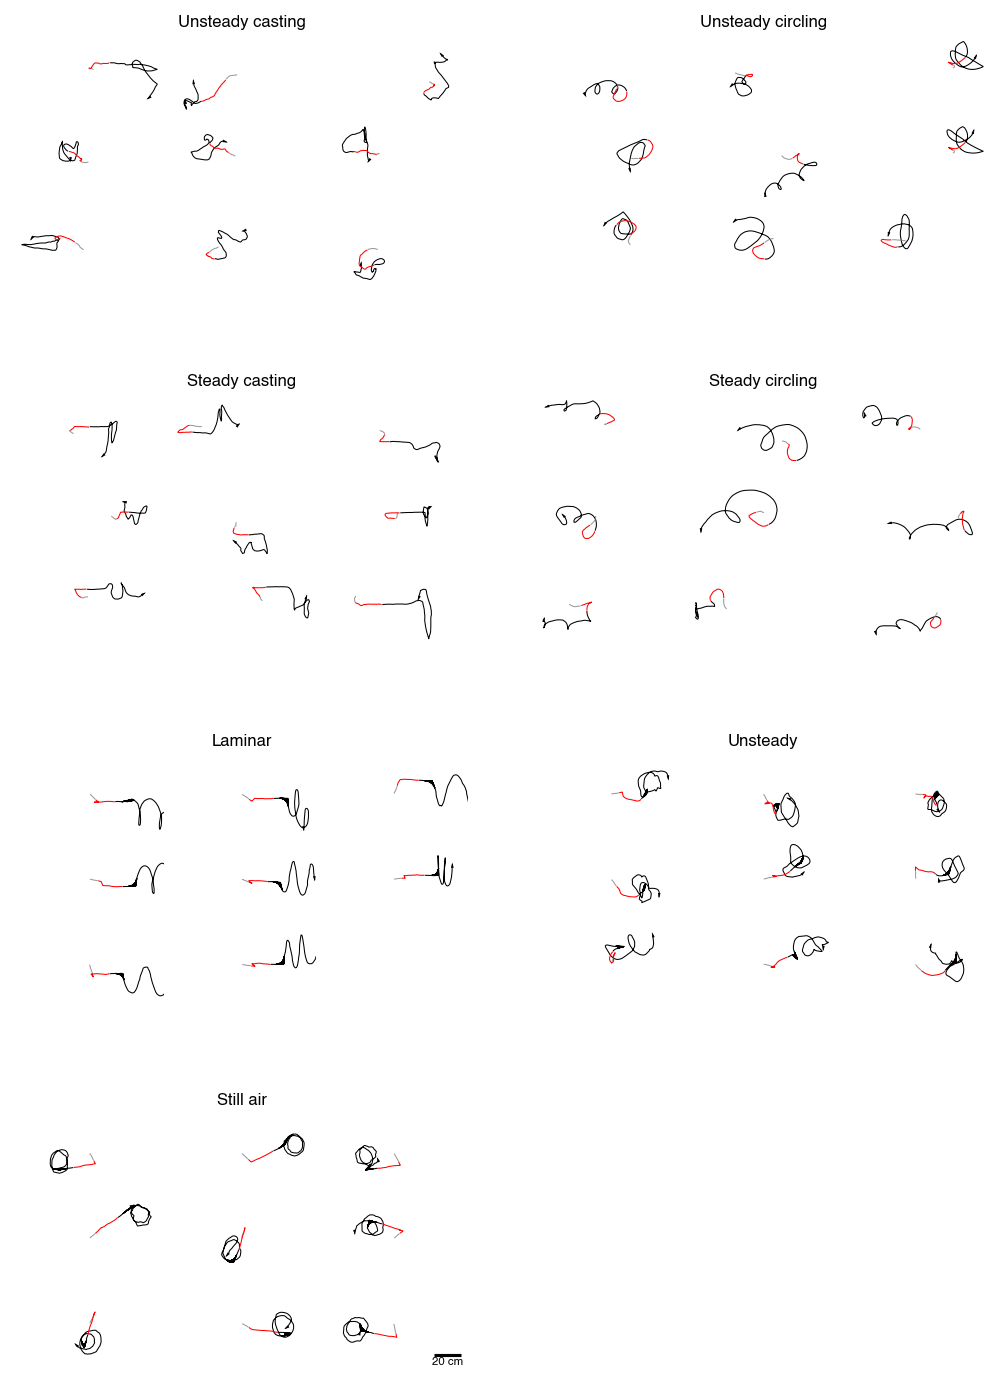

In [79]:
# 7 conditions → 4 rows × 2 cols (last cell empty)
N_PANEL_ROWS = (len(conditions) + 1) // 2
N_PANEL_COLS = 2

fig = plt.figure(figsize=(8.5, 11))
L, R = 1 / 8.5, 7.5 / 8.5
B, T = 1 / 11,  10 / 11

outer_gs = GridSpec(
    N_PANEL_ROWS, N_PANEL_COLS, figure=fig,
    left=L, right=R, bottom=B, top=T,
    wspace=0.15, hspace=0.32,
)

for i, cond in enumerate(conditions):
    p_row, p_col        = divmod(i, N_PANEL_COLS)
    qualified, traj_ids = sampled[cond["label"]]
    is_last_panel       = (i == len(conditions) - 1)

    inner_gs = GridSpecFromSubplotSpec(
        N_TRAJ_ROWS + 1, N_TRAJ_COLS,
        subplot_spec=outer_gs[p_row, p_col],
        wspace=0.02, hspace=0.02,
        height_ratios=[0.2] + [1] * N_TRAJ_ROWS,
    )

    ax_t = fig.add_subplot(inner_gs[0, :])
    ax_t.text(0.5, 0.15, cond["label"],
              transform=ax_t.transAxes, ha="center", va="bottom",
              fontsize=8, fontweight="bold")
    ax_t.axis("off")

    for j, traj_id in enumerate(traj_ids):
        r  = j // N_TRAJ_COLS + 1
        c  = j %  N_TRAJ_COLS
        ax = fig.add_subplot(inner_gs[r, c])
        plot_trajectory(
            qualified, traj_id, ax, XLIM, YLIM,
            flash_end_sec=FLASH_END_SEC,
            max_time_sec=MAX_TIME_SEC,
            lw=LW, arrow_length=ARROW_LENGTH,
            scale_bar=(is_last_panel and j == N_TRAJS - 1),
        )

OUT_PATH = NB_DIR / "combined_synthetic_trajectories.svg"
fig.savefig(OUT_PATH, format="svg", bbox_inches="tight")
print(f"Saved: {OUT_PATH}")
plt.show()